# How 2×2 Matrix Elements Work

## Purpose

Understand what each element of a 2×2 matrix contributes to a transformation.

The previous notebook introduced matrix-vector multiplication as:

$$
A @ v
$$

meaning:

> apply matrix \(A\) to vector \(v\)

This notebook looks inside a 2×2 matrix and asks:

> what does each individual entry actually do?

## Helpers

These helpers plot a few reference vectors and their transformed versions.

For most examples, we will use:

$$
e_1 = [1, 0]
$$

$$
e_2 = [0, 1]
$$

and:

$$
v = [2, 1]
$$

The basis vectors \(e_1\) and \(e_2\) show what the matrix does to the x-axis and y-axis directions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_vector_plot(xlim=(-3, 3), ylim=(-3, 3), figsize=(5.5, 5.5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.08, 0.08),
    width=0.007,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def plot_matrix_effect(A, title, xlim=(-3, 3), ylim=(-3, 3)):
    e1 = np.array([1, 0])
    e2 = np.array([0, 1])
    v = np.array([2, 1])

    Ae1 = A @ e1
    Ae2 = A @ e2
    Av = A @ v

    fig, ax = setup_vector_plot(xlim=xlim, ylim=ylim)

    # Original reference vectors: small/thin
    draw_vector(ax, e1, label="e1", label_offset=(0.08, -0.22), width=0.004)
    draw_vector(ax, e2, label="e2", label_offset=(0.08, 0.08), width=0.004)
    draw_vector(ax, v, label="v", label_offset=(0.08, 0.08), width=0.004)

    # Transformed vectors: larger/thicker
    draw_vector(ax, Ae1, label="A @ e1", label_offset=(0.08, -0.32), width=0.010)
    draw_vector(ax, Ae2, label="A @ e2", label_offset=(0.08, 0.08), width=0.010)
    draw_vector(ax, Av, label="A @ v", label_offset=(0.08, 0.08), width=0.012)

    ax.set_title(title)
    plt.show()

    print("A:")
    print(A)
    print()
    print("A @ e1:", Ae1)
    print("A @ e2:", Ae2)
    print("A @ v :", Av)

## The general 2×2 matrix

A general 2×2 matrix can be written as:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

If:

$$
v =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

then:

$$
A v =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
\begin{bmatrix}
ax + by \\
cx + dy
\end{bmatrix}
$$

So the four entries have different jobs:

- \(a\): input x contributes to output x
- \(b\): input y contributes to output x
- \(c\): input x contributes to output y
- \(d\): input y contributes to output y

## The zero matrix: everything collapses

Start with the zero matrix:

$$
A =
\begin{bmatrix}
0 & 0 \\
0 & 0
\end{bmatrix}
$$

This sends every vector to the origin.

No input component contributes to any output component.

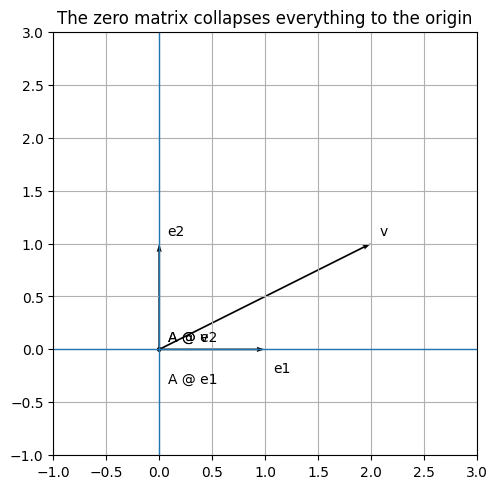

A:
[[0 0]
 [0 0]]

A @ e1: [0 0]
A @ e2: [0 0]
A @ v : [0 0]


In [2]:
A = np.array([
    [0, 0],
    [0, 0],
])

plot_matrix_effect(
    A,
    title="The zero matrix collapses everything to the origin",
    xlim=(-1, 3),
    ylim=(-1, 3),
)

The transformed basis vectors are both zero:

$$
A e_1 = [0, 0]
$$

$$
A e_2 = [0, 0]
$$

So the whole plane is collapsed into the origin.

## Building towards the identity matrix

The identity matrix is:

$$
I =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

It leaves vectors unchanged.

Before jumping straight to the identity matrix, build it one entry at a time.

## Top-left entry: x contributes to output x

First set only the top-left entry to 1:

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & 0
\end{bmatrix}
$$

For:

$$
v = [x, y]
$$

this gives:

$$
A v = [x, 0]
$$

The input x-coordinate survives.

The input y-coordinate is discarded.

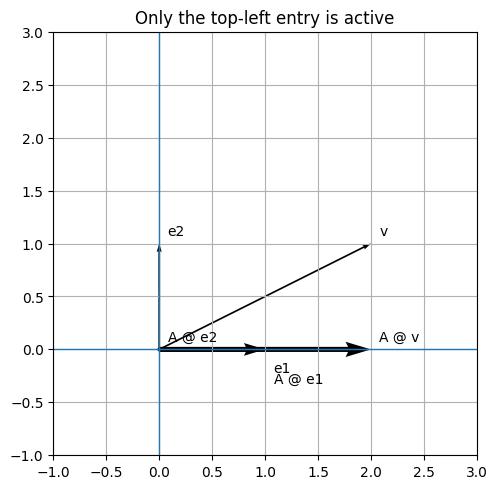

A:
[[1 0]
 [0 0]]

A @ e1: [1 0]
A @ e2: [0 0]
A @ v : [2 0]


In [3]:
A = np.array([
    [1, 0],
    [0, 0],
])

plot_matrix_effect(
    A,
    title="Only the top-left entry is active",
    xlim=(-1, 3),
    ylim=(-1, 3),
)

This flattens everything onto the x-axis.

The matrix keeps the x-part of a vector and throws away the y-part.

## Bottom-right entry: y contributes to output y

Now set only the bottom-right entry to 1:

$$
A =
\begin{bmatrix}
0 & 0 \\
0 & 1
\end{bmatrix}
$$

For:

$$
v = [x, y]
$$

this gives:

$$
A v = [0, y]
$$

The input y-coordinate survives.

The input x-coordinate is discarded.

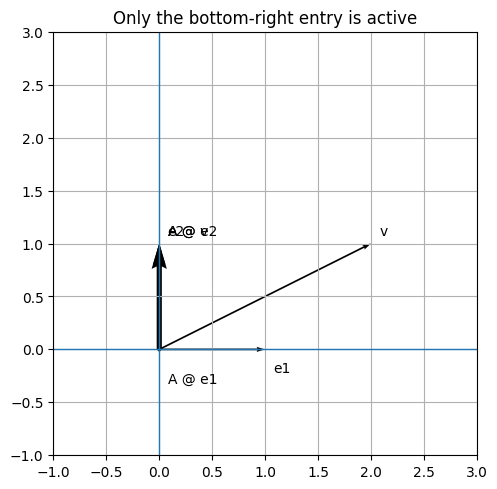

A:
[[0 0]
 [0 1]]

A @ e1: [0 0]
A @ e2: [0 1]
A @ v : [0 1]


In [4]:
A = np.array([
    [0, 0],
    [0, 1],
])

plot_matrix_effect(
    A,
    title="Only the bottom-right entry is active",
    xlim=(-1, 3),
    ylim=(-1, 3),
)

This flattens everything onto the y-axis.

The matrix keeps the y-part of a vector and throws away the x-part.

## The identity matrix: nothing changes

Now combine those two diagonal entries:

$$
I =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

For:

$$
v = [x, y]
$$

this gives:

$$
I v = [x, y]
$$

The x-coordinate contributes to output x.

The y-coordinate contributes to output y.

There is no mixing between x and y.

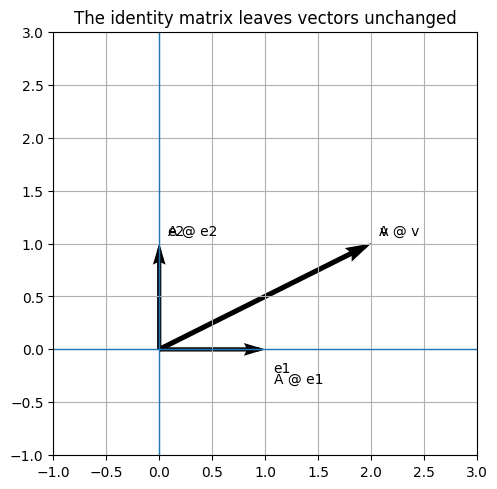

A:
[[1 0]
 [0 1]]

A @ e1: [1 0]
A @ e2: [0 1]
A @ v : [2 1]


In [5]:
I = np.array([
    [1, 0],
    [0, 1],
])

plot_matrix_effect(
    I,
    title="The identity matrix leaves vectors unchanged",
    xlim=(-1, 3),
    ylim=(-1, 3),
)

The identity matrix is the “do nothing” transformation.

It is useful because other transformations can be understood as departures from this simple baseline.

## Varying the top-left entry \(a\)

Now vary the top-left entry:

$$
A =
\begin{bmatrix}
a & 0 \\
0 & 1
\end{bmatrix}
$$

This controls how much input x contributes to output x.

The y-coordinate still behaves normally.

In [6]:
v = np.array([2, 1])

for a in [0.5, 1, 2, -1]:
    A = np.array([
        [a, 0],
        [0, 1],
    ])

    print(f"a = {a}")
    print("A @ v:", A @ v)
    print()

a = 0.5
A @ v: [1. 1.]

a = 1
A @ v: [2 1]

a = 2
A @ v: [4 1]

a = -1
A @ v: [-2  1]



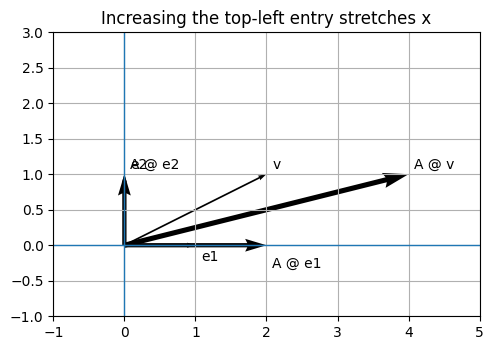

A:
[[2 0]
 [0 1]]

A @ e1: [2 0]
A @ e2: [0 1]
A @ v : [4 1]


In [7]:
A = np.array([
    [2, 0],
    [0, 1],
])

plot_matrix_effect(
    A,
    title="Increasing the top-left entry stretches x",
    xlim=(-1, 5),
    ylim=(-1, 3),
)

Increasing \(a\) stretches the x-direction.

Making \(a\) negative flips the x-direction.

So the top-left entry affects the x-axis basis direction:

$$
A e_1 = [a, 0]
$$

## Varying the bottom-right entry \(d\)

Now vary the bottom-right entry:

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & d
\end{bmatrix}
$$

This controls how much input y contributes to output y.

The x-coordinate still behaves normally.

In [8]:
v = np.array([2, 1])

for d in [0.5, 1, 2, -1]:
    A = np.array([
        [1, 0],
        [0, d],
    ])

    print(f"d = {d}")
    print("A @ v:", A @ v)
    print()

d = 0.5
A @ v: [2.  0.5]

d = 1
A @ v: [2 1]

d = 2
A @ v: [2 2]

d = -1
A @ v: [ 2 -1]



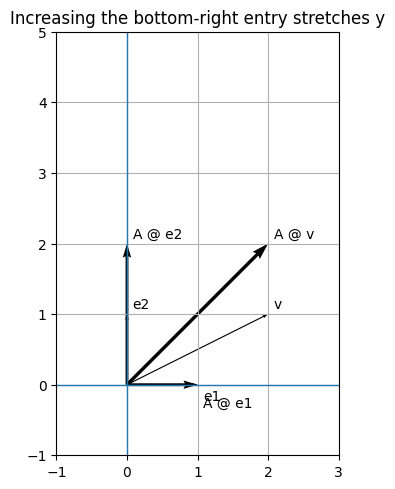

A:
[[1 0]
 [0 2]]

A @ e1: [1 0]
A @ e2: [0 2]
A @ v : [2 2]


In [9]:
A = np.array([
    [1, 0],
    [0, 2],
])

plot_matrix_effect(
    A,
    title="Increasing the bottom-right entry stretches y",
    xlim=(-1, 3),
    ylim=(-1, 5),
)

Increasing \(d\) stretches the y-direction.

Making \(d\) negative flips the y-direction.

So the bottom-right entry affects the y-axis basis direction:

$$
A e_2 = [0, d]
$$

## Varying the top-right entry \(b\)

Now vary the top-right entry:

$$
A =
\begin{bmatrix}
1 & b \\
0 & 1
\end{bmatrix}
$$

This controls how much input y contributes to output x.

This is a mixing entry: y affects x.

For:

$$
v = [x, y]
$$

we get:

$$
A v = [x + by, y]
$$

In [10]:
v = np.array([2, 1])

for b in [-1, 0, 1, 2]:
    A = np.array([
        [1, b],
        [0, 1],
    ])

    print(f"b = {b}")
    print("A @ v:", A @ v)
    print()

b = -1
A @ v: [1 1]

b = 0
A @ v: [2 1]

b = 1
A @ v: [3 1]

b = 2
A @ v: [4 1]



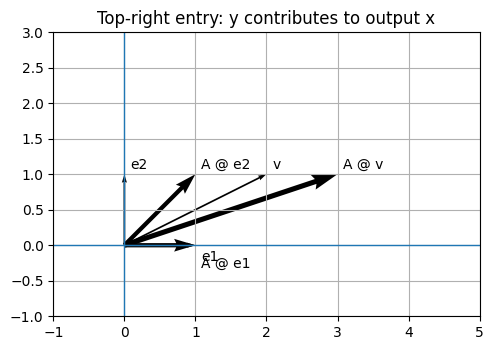

A:
[[1 1]
 [0 1]]

A @ e1: [1 0]
A @ e2: [1 1]
A @ v : [3 1]


In [11]:
A = np.array([
    [1, 1],
    [0, 1],
])

plot_matrix_effect(
    A,
    title="Top-right entry: y contributes to output x",
    xlim=(-1, 5),
    ylim=(-1, 3),
)

This produces a horizontal shear.

The y-coordinate stays the same, but points higher up get pushed sideways more.

The top-right entry changes where \(e_2\) goes:

$$
A e_2 = [b, 1]
$$

## Varying the bottom-left entry \(c\)

Now vary the bottom-left entry:

$$
A =
\begin{bmatrix}
1 & 0 \\
c & 1
\end{bmatrix}
$$

This controls how much input x contributes to output y.

This is the other mixing entry: x affects y.

For:

$$
v = [x, y]
$$

we get:

$$
A v = [x, cx + y]
$$

In [12]:
v = np.array([2, 1])

for c in [-1, 0, 1, 2]:
    A = np.array([
        [1, 0],
        [c, 1],
    ])

    print(f"c = {c}")
    print("A @ v:", A @ v)
    print()

c = -1
A @ v: [ 2 -1]

c = 0
A @ v: [2 1]

c = 1
A @ v: [2 3]

c = 2
A @ v: [2 5]



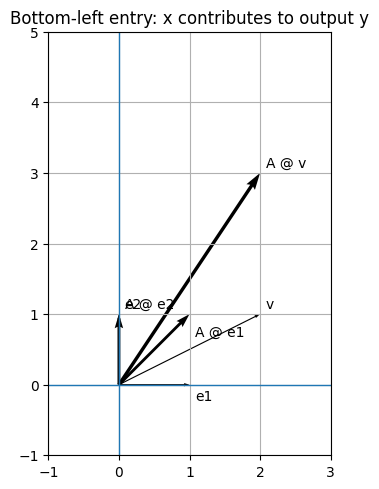

A:
[[1 0]
 [1 1]]

A @ e1: [1 1]
A @ e2: [0 1]
A @ v : [2 3]


In [13]:
A = np.array([
    [1, 0],
    [1, 1],
])

plot_matrix_effect(
    A,
    title="Bottom-left entry: x contributes to output y",
    xlim=(-1, 3),
    ylim=(-1, 5),
)

This produces a vertical shear.

The x-coordinate stays the same, but points farther to the right get pushed upward more.

The bottom-left entry changes where \(e_1\) goes:

$$
A e_1 = [1, c]
$$

## Reading columns as transformed basis vectors

The row-by-row view is useful for calculation:

$$
A v =
\begin{bmatrix}
ax + by \\
cx + dy
\end{bmatrix}
$$

But the column view is often better for understanding transformations.

For:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

the columns are:

$$
\begin{bmatrix}
a \\
c
\end{bmatrix}
$$

and:

$$
\begin{bmatrix}
b \\
d
\end{bmatrix}
$$

Those columns are exactly where the basis vectors go:

$$
A e_1 =
\begin{bmatrix}
a \\
c
\end{bmatrix}
$$

$$
A e_2 =
\begin{bmatrix}
b \\
d
\end{bmatrix}
$$

In [14]:
A = np.array([
    [2, 1],
    [1, 3],
])

e1 = np.array([1, 0])
e2 = np.array([0, 1])

print("A:")
print(A)
print()
print("first column:", A[:, 0])
print("A @ e1:     ", A @ e1)
print()
print("second column:", A[:, 1])
print("A @ e2:      ", A @ e2)

A:
[[2 1]
 [1 3]]

first column: [2 1]
A @ e1:      [2 1]

second column: [1 3]
A @ e2:       [1 3]


This is the big idea:

> changing the first column changes where the x-axis basis vector goes

and:

> changing the second column changes where the y-axis basis vector goes

That is why the column view is so useful for visualising matrix transformations.

## Summary

For a 2×2 matrix:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

and a vector:

$$
v = [x, y]
$$

the output is:

$$
A v = [ax + by, cx + dy]
$$

So:

- \(a\): input x contributes to output x
- \(b\): input y contributes to output x
- \(c\): input x contributes to output y
- \(d\): input y contributes to output y

Another way to read the matrix is by columns:

- first column = where \(e_1\) goes
- second column = where \(e_2\) goes

## Next step

Next, look at named transformations such as scaling, reflection and shear.

Those transformations are built from the same four matrix entries.